<a href="https://colab.research.google.com/github/Niyatij30/ascad-side-channel-aes-ml/blob/main/notebooks/data_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install h5py scikit-learn matplotlib numpy

In [3]:
!wget https://static.data.gouv.fr/resources/ascad-atmega-8515-variable-key/20190903-083349/ascad-variable.h5 -O ASCAD.h5

--2026-07-19 21:58:26--  https://static.data.gouv.fr/resources/ascad-atmega-8515-variable-key/20190903-083349/ascad-variable.h5
Resolving static.data.gouv.fr (static.data.gouv.fr)... 37.59.183.92, 37.59.183.73, 37.59.183.91
Connecting to static.data.gouv.fr (static.data.gouv.fr)|37.59.183.92|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 438606904 (418M) [application/octet-stream]
Saving to: ‘ASCAD.h5’

ASCAD.h5            100%[===================>] 418.29M  12.2MB/s    in 36s     

2026-07-19 21:59:03 (11.6 MB/s) - ‘ASCAD.h5’ saved [438606904/438606904]



In [6]:
import os

print("Downloaded:", os.path.exists("ASCAD.h5"))
print("File size:", round(os.path.getsize("ASCAD.h5")/(1024**2),2), "MB")

Downloaded: True
File size: 418.29 MB


In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

f = h5py.File("ASCAD.h5", "r")

In [8]:
print("Top-level groups:")
print(list(f.keys()))

Top-level groups:
['Attack_traces', 'Profiling_traces']


In [9]:
profiling = f["Profiling_traces"]
attack = f["Attack_traces"]

print(profiling.keys())
print(attack.keys())

<KeysViewHDF5 ['labels', 'metadata', 'traces']>
<KeysViewHDF5 ['labels', 'metadata', 'traces']>


In [10]:
traces = profiling["traces"]

print("Shape of traces:")
print(traces.shape)

Shape of traces:
(200000, 1400)


In [11]:
metadata = profiling["metadata"]

print(metadata.dtype.names)

('plaintext', 'key', 'masks', 'desync')


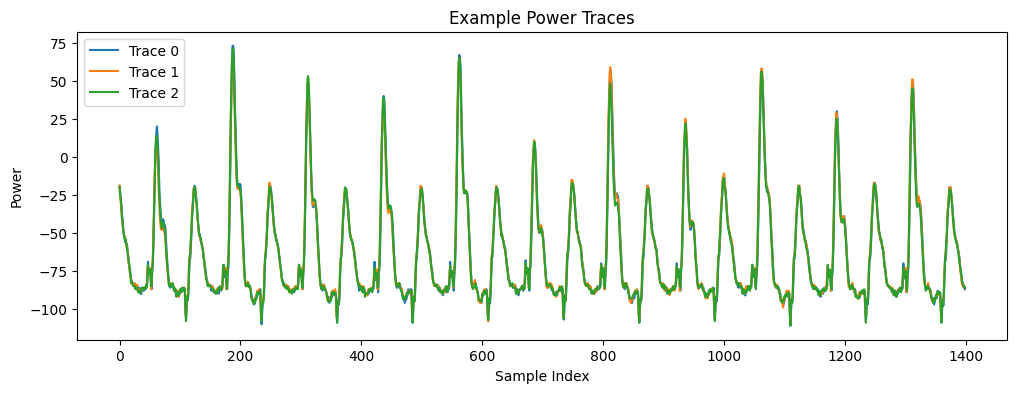

In [12]:
plt.figure(figsize=(12,4))

for i in range(3):
    plt.plot(traces[i], label=f"Trace {i}")

plt.xlabel("Sample Index")
plt.ylabel("Power")
plt.title("Example Power Traces")
plt.legend()
plt.show()

In [13]:
print("Plaintext:")
print(metadata["plaintext"][0])

print()

print("Key:")
print(metadata["key"][0])

Plaintext:
[177  53 190  28 100 167 157  30 232  88  18  33  39  17  78  91]

Key:
[  7 171 173  86 108  64 254  56   2  77 167  43 153  53 248 169]


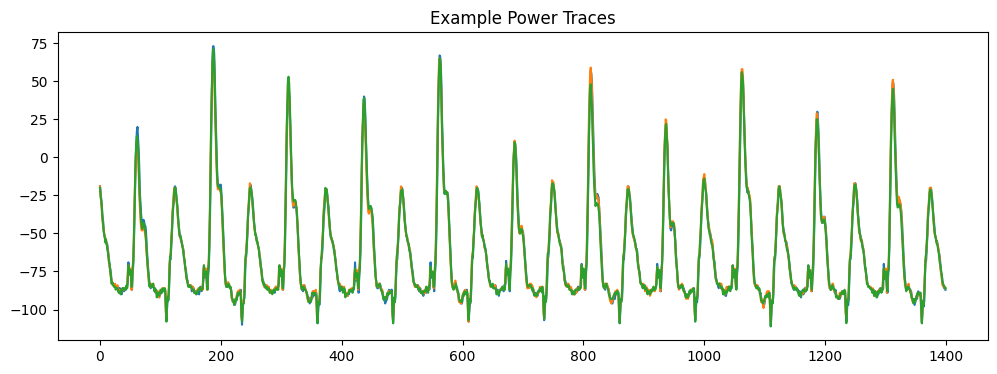

In [14]:
import os

os.makedirs("results", exist_ok=True)

plt.figure(figsize=(12,4))

for i in range(3):
    plt.plot(traces[i])

plt.title("Example Power Traces")

plt.savefig("results/example_traces.png")
plt.show()